<a href="https://colab.research.google.com/github/Arpit-0409/Loan_Approva_Prediction_System/blob/main/Loan_Approval_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [846]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline

In [847]:
loan_df = pd.read_csv("data.csv")

In [848]:
loan_df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
427,428.0,14144.0,6154.0,Contract,46.0,Married,2.0,742.0,0.0,0.58,15608.0,49220.0,12802.0,84.0,Personal,Urban,Graduate,Male,Business,No
470,471.0,15807.0,552.0,Salaried,56.0,NaN,1.0,569.0,1.0,0.26,5782.0,31269.0,NaN,36.0,Home,Rural,Graduate,Female,MNC,No
162,163.0,2197.0,6640.0,Salaried,56.0,Married,3.0,NaN,NaN,0.14,17376.0,14193.0,19677.0,84.0,Education,Rural,Not Graduate,Male,Private,No
243,244.0,11151.0,NaN,NaN,37.0,Married,2.0,700.0,3.0,0.31,17073.0,29714.0,19040.0,48.0,Home,Urban,Graduate,Female,Government,Yes
64,65.0,19262.0,4853.0,NaN,21.0,Married,0.0,551.0,3.0,0.36,4016.0,1746.0,39995.0,60.0,Business,Urban,Graduate,Female,Government,No
271,NaN,NaN,5233.0,Salaried,36.0,Married,0.0,767.0,3.0,0.25,5041.0,49906.0,29804.0,48.0,Education,Rural,Not Graduate,Male,MNC,Yes
435,NaN,16512.0,3762.0,Self-employed,53.0,Married,1.0,616.0,1.0,0.32,14780.0,3598.0,23191.0,72.0,Home,Rural,Graduate,Male,Government,No
844,845.0,12147.0,3374.0,Contract,32.0,Married,1.0,757.0,0.0,NaN,16059.0,20446.0,13262.0,60.0,Home,Semiurban,Graduate,Male,Business,Yes
498,499.0,15428.0,2356.0,Salaried,41.0,Married,NaN,745.0,1.0,0.31,15257.0,12468.0,23161.0,24.0,Education,Urban,Graduate,Male,Private,Yes
751,752.0,8283.0,5203.0,Salaried,22.0,Single,1.0,629.0,1.0,0.45,8252.0,10360.0,9747.0,12.0,Business,Urban,Graduate,NaN,Government,No


In [849]:
#encode target column -
loan_df["Loan_Approved"] = loan_df["Loan_Approved"].map({"Yes":1,"No":0})


In [850]:
loan_df["Loan_Approved"].value_counts()

,count
Loan_Approved,
0.0,652
1.0,298


In [851]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [852]:
#null values
loan_df.isnull().mean()*100


,0
Applicant_ID,5.0
Applicant_Income,5.0
Coapplicant_Income,5.0
Employment_Status,5.0
Age,5.0
Marital_Status,5.0
Dependents,5.0
Credit_Score,5.0
Existing_Loans,5.0
DTI_Ratio,5.0


Handling Target COLUMN MISSING VALUES

In [853]:
#Rmoved Missing value from Target column in original loan_df and store it in loan_test_df for future testing
loan_test_df = loan_df[loan_df["Loan_Approved"].isnull()]
loan_df.dropna(subset=["Loan_Approved"],inplace=True)
# Reset the index numbers so they are sequential again
loan_df.reset_index(drop=True, inplace=True)

loan_df["Loan_Approved"] = loan_df["Loan_Approved"].astype(int)


In [854]:
loan_test_df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
15,16.0,7311.0,1301.0,Salaried,42.0,Married,3.0,710.0,4.0,0.48,9908.0,24561.0,9120.0,72.0,Personal,Urban,Not Graduate,Female,Private,NaN
26,27.0,19912.0,5796.0,Contract,28.0,Single,1.0,568.0,1.0,0.16,16884.0,25060.0,11679.0,84.0,Personal,Urban,Graduate,Male,Government,NaN
100,101.0,8910.0,6960.0,Self-employed,23.0,Single,3.0,789.0,2.0,0.52,16450.0,32761.0,11412.0,36.0,Business,Urban,Graduate,Female,Government,NaN
122,123.0,5627.0,8044.0,Self-employed,30.0,Married,3.0,700.0,0.0,0.14,1184.0,39618.0,17292.0,72.0,Home,Rural,Graduate,Male,NaN,NaN
191,NaN,11208.0,1165.0,Salaried,43.0,Single,2.0,781.0,1.0,0.50,13579.0,41797.0,19907.0,72.0,Education,Rural,Not Graduate,Female,MNC,NaN
195,196.0,4049.0,145.0,Salaried,47.0,Married,0.0,753.0,3.0,0.37,15903.0,24756.0,34932.0,84.0,Business,Semiurban,Graduate,Male,Private,NaN
263,264.0,2190.0,5295.0,Contract,49.0,Single,3.0,597.0,3.0,0.53,12004.0,40581.0,28584.0,72.0,Business,Urban,Graduate,NaN,Private,NaN
290,291.0,18921.0,2604.0,Self-employed,23.0,Single,1.0,798.0,3.0,0.29,16080.0,21957.0,NaN,60.0,Education,Urban,Graduate,Female,Government,NaN
293,294.0,10716.0,3738.0,Self-employed,38.0,Single,0.0,673.0,1.0,0.51,1971.0,12771.0,8292.0,NaN,Business,Semiurban,NaN,Female,Business,NaN
310,311.0,NaN,294.0,Salaried,39.0,Single,2.0,705.0,3.0,NaN,3542.0,39551.0,29109.0,12.0,Car,Urban,Graduate,Male,Government,NaN


In [855]:
# after removing misssing rows using loan_approved(targetvariable)
loan_df.shape

(950, 20)

In [856]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        902 non-null    float64
 1   Applicant_Income    902 non-null    float64
 2   Coapplicant_Income  902 non-null    float64
 3   Employment_Status   906 non-null    object 
 4   Age                 902 non-null    float64
 5   Marital_Status      902 non-null    object 
 6   Dependents          903 non-null    float64
 7   Credit_Score        902 non-null    float64
 8   Existing_Loans      901 non-null    float64
 9   DTI_Ratio           903 non-null    float64
 10  Savings             901 non-null    float64
 11  Collateral_Value    901 non-null    float64
 12  Loan_Amount         903 non-null    float64
 13  Loan_Term           902 non-null    float64
 14  Loan_Purpose        902 non-null    object 
 15  Property_Area       901 non-null    object 
 16  Educatio

In [857]:
loan_df.isnull().mean()*100


,0
Applicant_ID,5.052632
Applicant_Income,5.052632
Coapplicant_Income,5.052632
Employment_Status,4.631579
Age,5.052632
Marital_Status,5.052632
Dependents,4.947368
Credit_Score,5.052632
Existing_Loans,5.157895
DTI_Ratio,4.947368


In [858]:
# extracting input numerical features name
numeric_cols =loan_df.select_dtypes(include=["number"]).columns.drop(["Loan_Approved"],errors ="ignore")
categorical_cols =loan_df.select_dtypes(include=["object"]).columns.drop(["Loan_Approved"],errors ="ignore")


In [859]:
numeric_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [860]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='object')

In [861]:
loan_df.shape

(950, 20)

In [862]:
cpy_df = loan_df.copy()

In [863]:
numeric_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

INPUT  NUMERICAL COLUMNS HANDLING MISSING VALUES

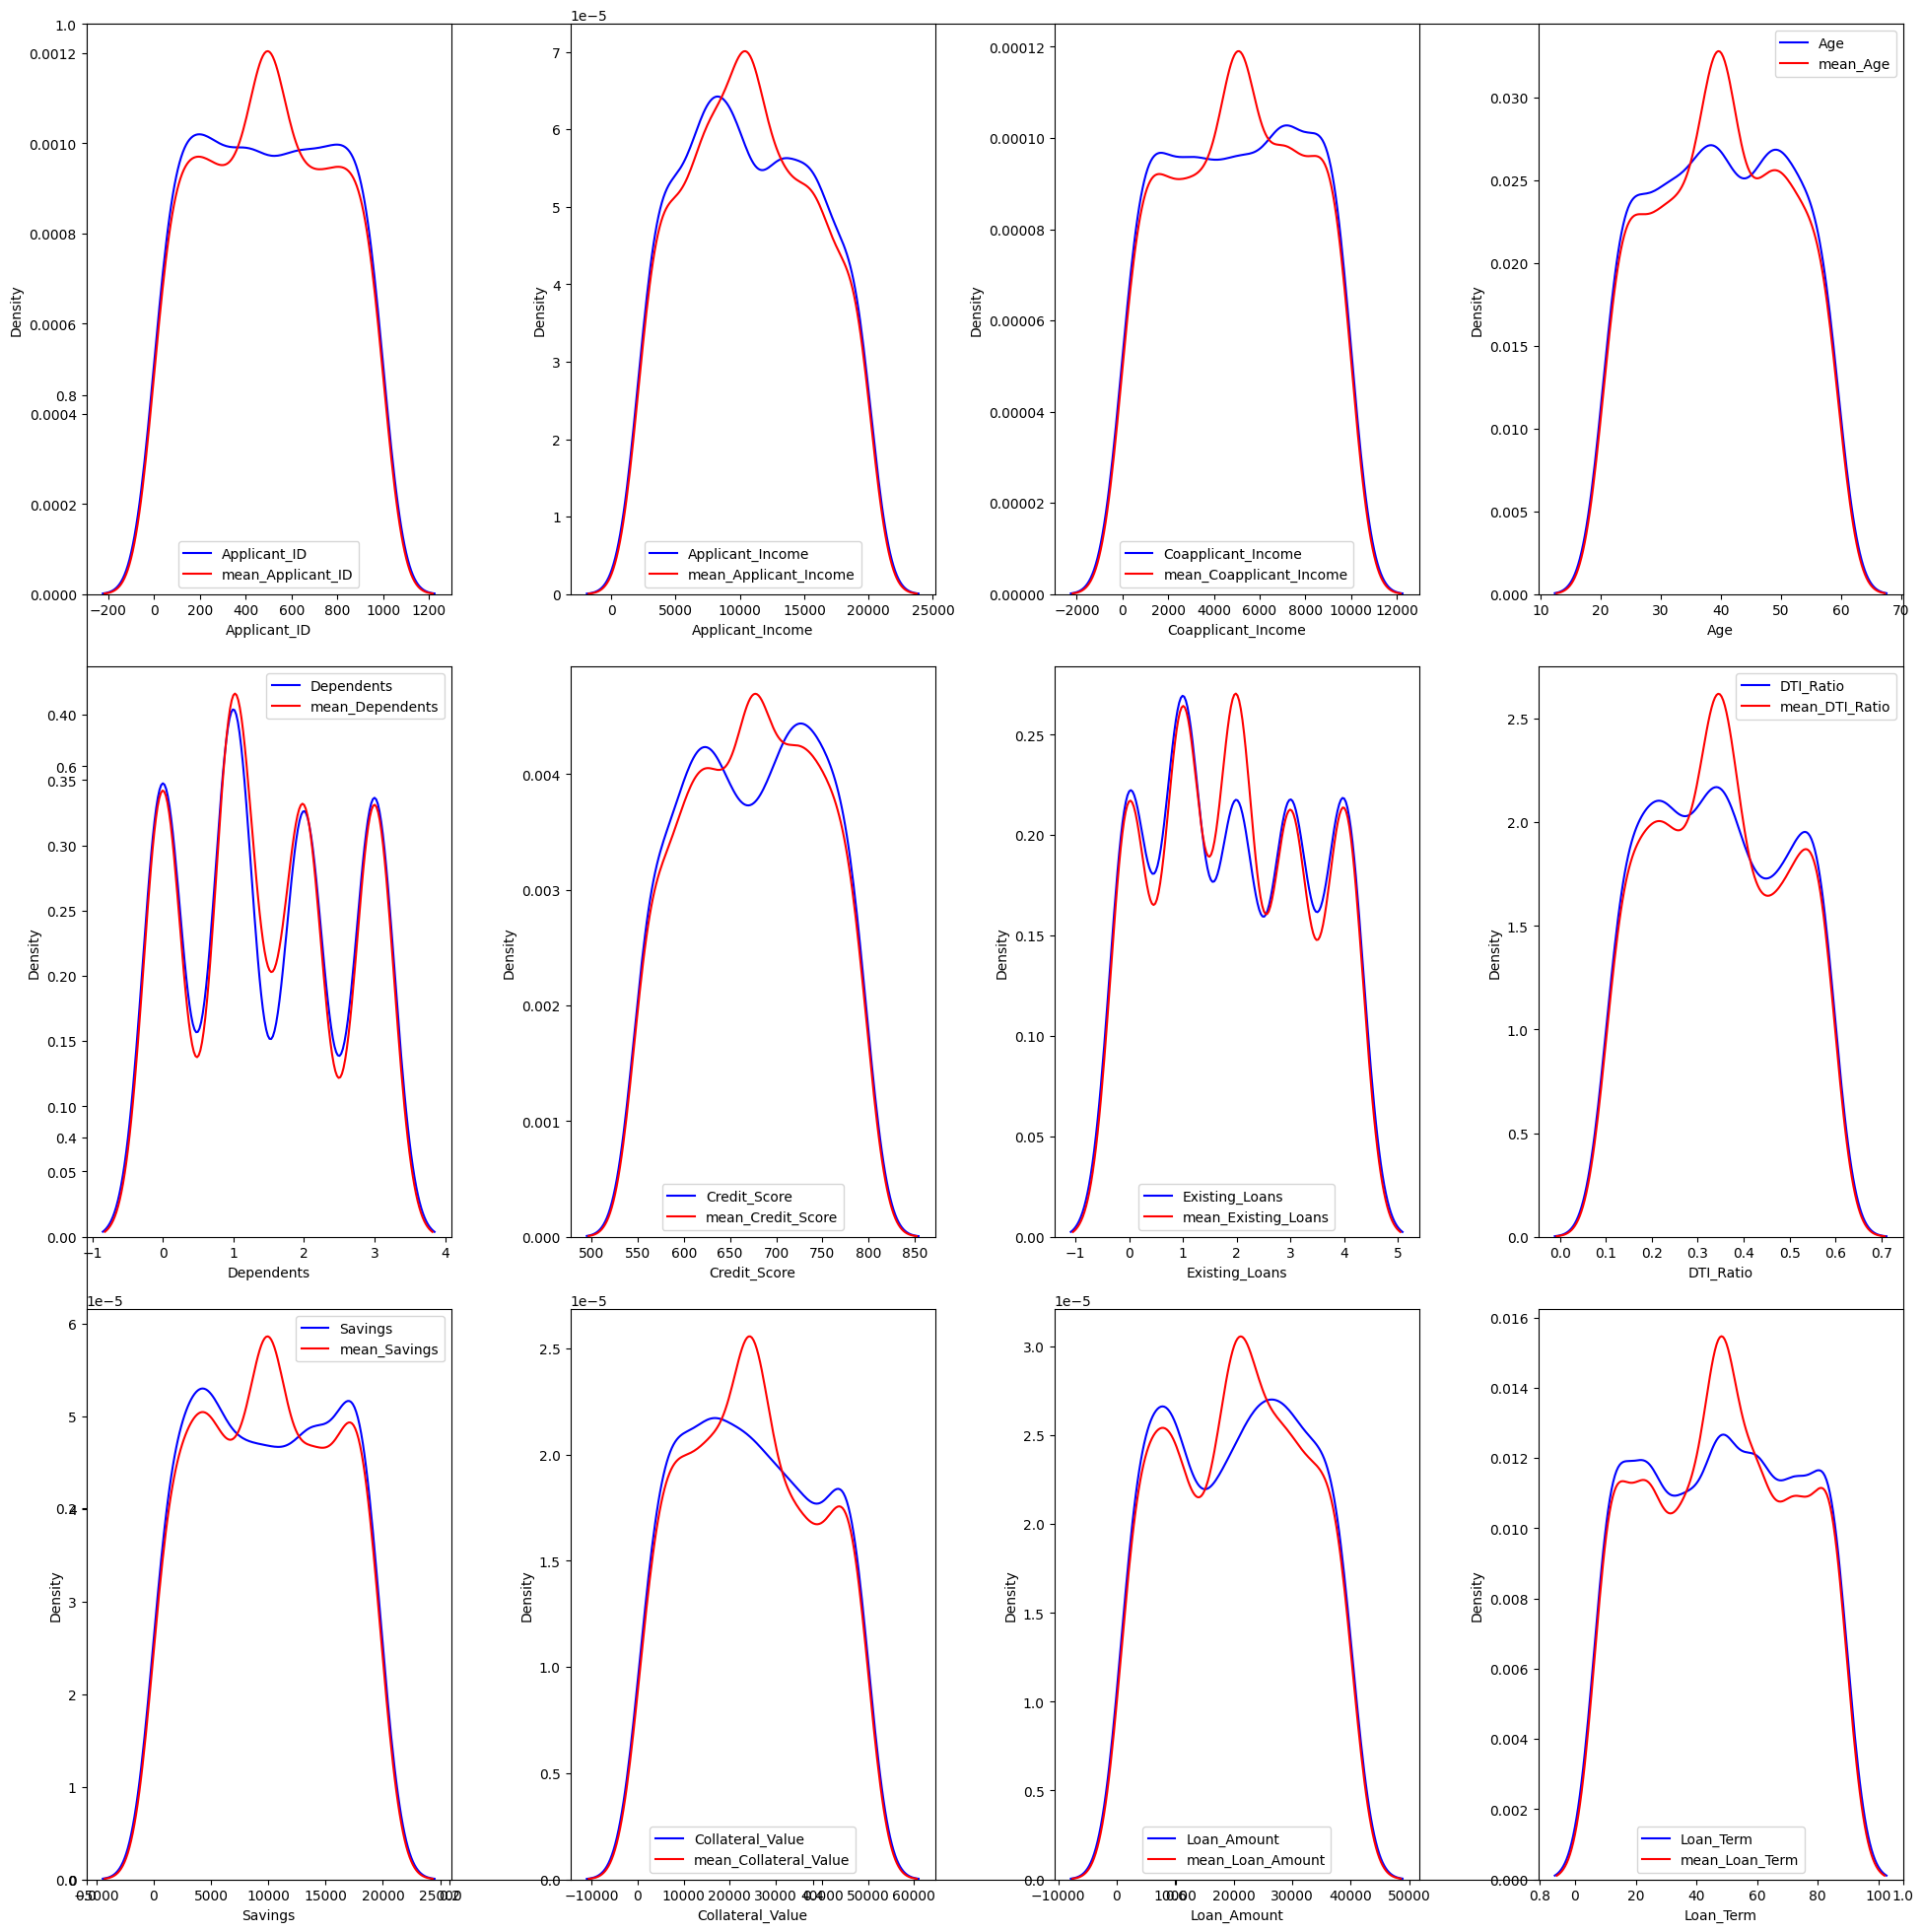

In [864]:
si = SimpleImputer(strategy="mean")
cpy_df[numeric_cols] = si.fit_transform(cpy_df[numeric_cols])

fig , ax = plt.subplots(figsize=(20,20))
plt.subplot(3,4,1)
sns.kdeplot(loan_df["Applicant_ID"],color="blue",label="Applicant_ID")
sns.kdeplot(cpy_df["Applicant_ID"],color="red",label="mean_Applicant_ID")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,2)
sns.kdeplot(loan_df["Applicant_Income"],color="blue",label="Applicant_Income")
sns.kdeplot(cpy_df["Applicant_Income"],color="red",label="mean_Applicant_Income")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,3)
sns.kdeplot(loan_df["Coapplicant_Income"],color="blue",label="Coapplicant_Income")
sns.kdeplot(cpy_df["Coapplicant_Income"],color="red",label="mean_Coapplicant_Income")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,4)
sns.kdeplot(loan_df["Age"],color="blue",label="Age")
sns.kdeplot(cpy_df["Age"],color="red",label="mean_Age")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,5)
sns.kdeplot(loan_df["Dependents"],color="blue",label="Dependents")
sns.kdeplot(cpy_df["Dependents"],color="red",label="mean_Dependents")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,6)
sns.kdeplot(loan_df["Credit_Score"],color="blue",label="Credit_Score")
sns.kdeplot(cpy_df["Credit_Score"],color="red",label="mean_Credit_Score")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,7)
sns.kdeplot(loan_df["Existing_Loans"],color="blue",label="Existing_Loans")
sns.kdeplot(cpy_df["Existing_Loans"],color="red",label="mean_Existing_Loans")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,8)
sns.kdeplot(loan_df["DTI_Ratio"],color="blue",label="DTI_Ratio")
sns.kdeplot(cpy_df["DTI_Ratio"],color="red",label="mean_DTI_Ratio")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,9)
sns.kdeplot(loan_df["Savings"],color="blue",label="Savings")
sns.kdeplot(cpy_df["Savings"],color="red",label="mean_Savings")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,10)
sns.kdeplot(loan_df["Collateral_Value"],color="blue",label="Collateral_Value")
sns.kdeplot(cpy_df["Collateral_Value"],color="red",label="mean_Collateral_Value")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,11)
sns.kdeplot(loan_df["Loan_Amount"],color="blue",label="Loan_Amount")
sns.kdeplot(cpy_df["Loan_Amount"],color="red",label="mean_Loan_Amount")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,12)
sns.kdeplot(loan_df["Loan_Term"],color="blue",label="Loan_Term")
sns.kdeplot(cpy_df["Loan_Term"],color="red",label="mean_Loan_Term")
plt.tight_layout()
plt.legend()

plt.show()












In [865]:

cpy2_df = loan_df.copy()

In [866]:
numeric_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [867]:
#Random Imputation
cpy2_df.loc[cpy2_df["Applicant_ID"].isnull(),"Applicant_ID"] = cpy2_df["Applicant_ID"].dropna().sample(cpy2_df["Applicant_ID"].isnull().sum()).values

In [868]:
cpy2_df.loc[cpy2_df["Applicant_Income"].isnull(),"Applicant_Income"] = cpy2_df["Applicant_Income"].dropna().sample(cpy2_df["Applicant_Income"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Coapplicant_Income"].isnull(),"Coapplicant_Income"] = cpy2_df["Coapplicant_Income"].dropna().sample(cpy2_df["Coapplicant_Income"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Age"].isnull(),"Age"] = cpy2_df["Age"].dropna().sample(cpy2_df["Age"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Dependents"].isnull(),"Dependents"] = cpy2_df["Dependents"].dropna().sample(cpy2_df["Dependents"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Credit_Score"].isnull(),"Credit_Score"] = cpy2_df["Credit_Score"].dropna().sample(cpy2_df["Credit_Score"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Existing_Loans"].isnull(),"Existing_Loans"] = cpy2_df["Existing_Loans"].dropna().sample(cpy2_df["Existing_Loans"].isnull().sum()).values
cpy2_df.loc[cpy2_df["DTI_Ratio"].isnull(),"DTI_Ratio"] = cpy2_df["DTI_Ratio"].dropna().sample(cpy2_df["DTI_Ratio"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Savings"].isnull(),"Savings"] = cpy2_df["Savings"].dropna().sample(cpy2_df["Savings"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Collateral_Value"].isnull(),"Collateral_Value"] = cpy2_df["Collateral_Value"].dropna().sample(cpy2_df["Collateral_Value"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Loan_Amount"].isnull(),"Loan_Amount"] = cpy2_df["Loan_Amount"].dropna().sample(cpy2_df["Loan_Amount"].isnull().sum()).values
cpy2_df.loc[cpy2_df["Loan_Term"].isnull(),"Loan_Term"] = cpy2_df["Loan_Term"].dropna().sample(cpy2_df["Loan_Term"].isnull().sum()).values


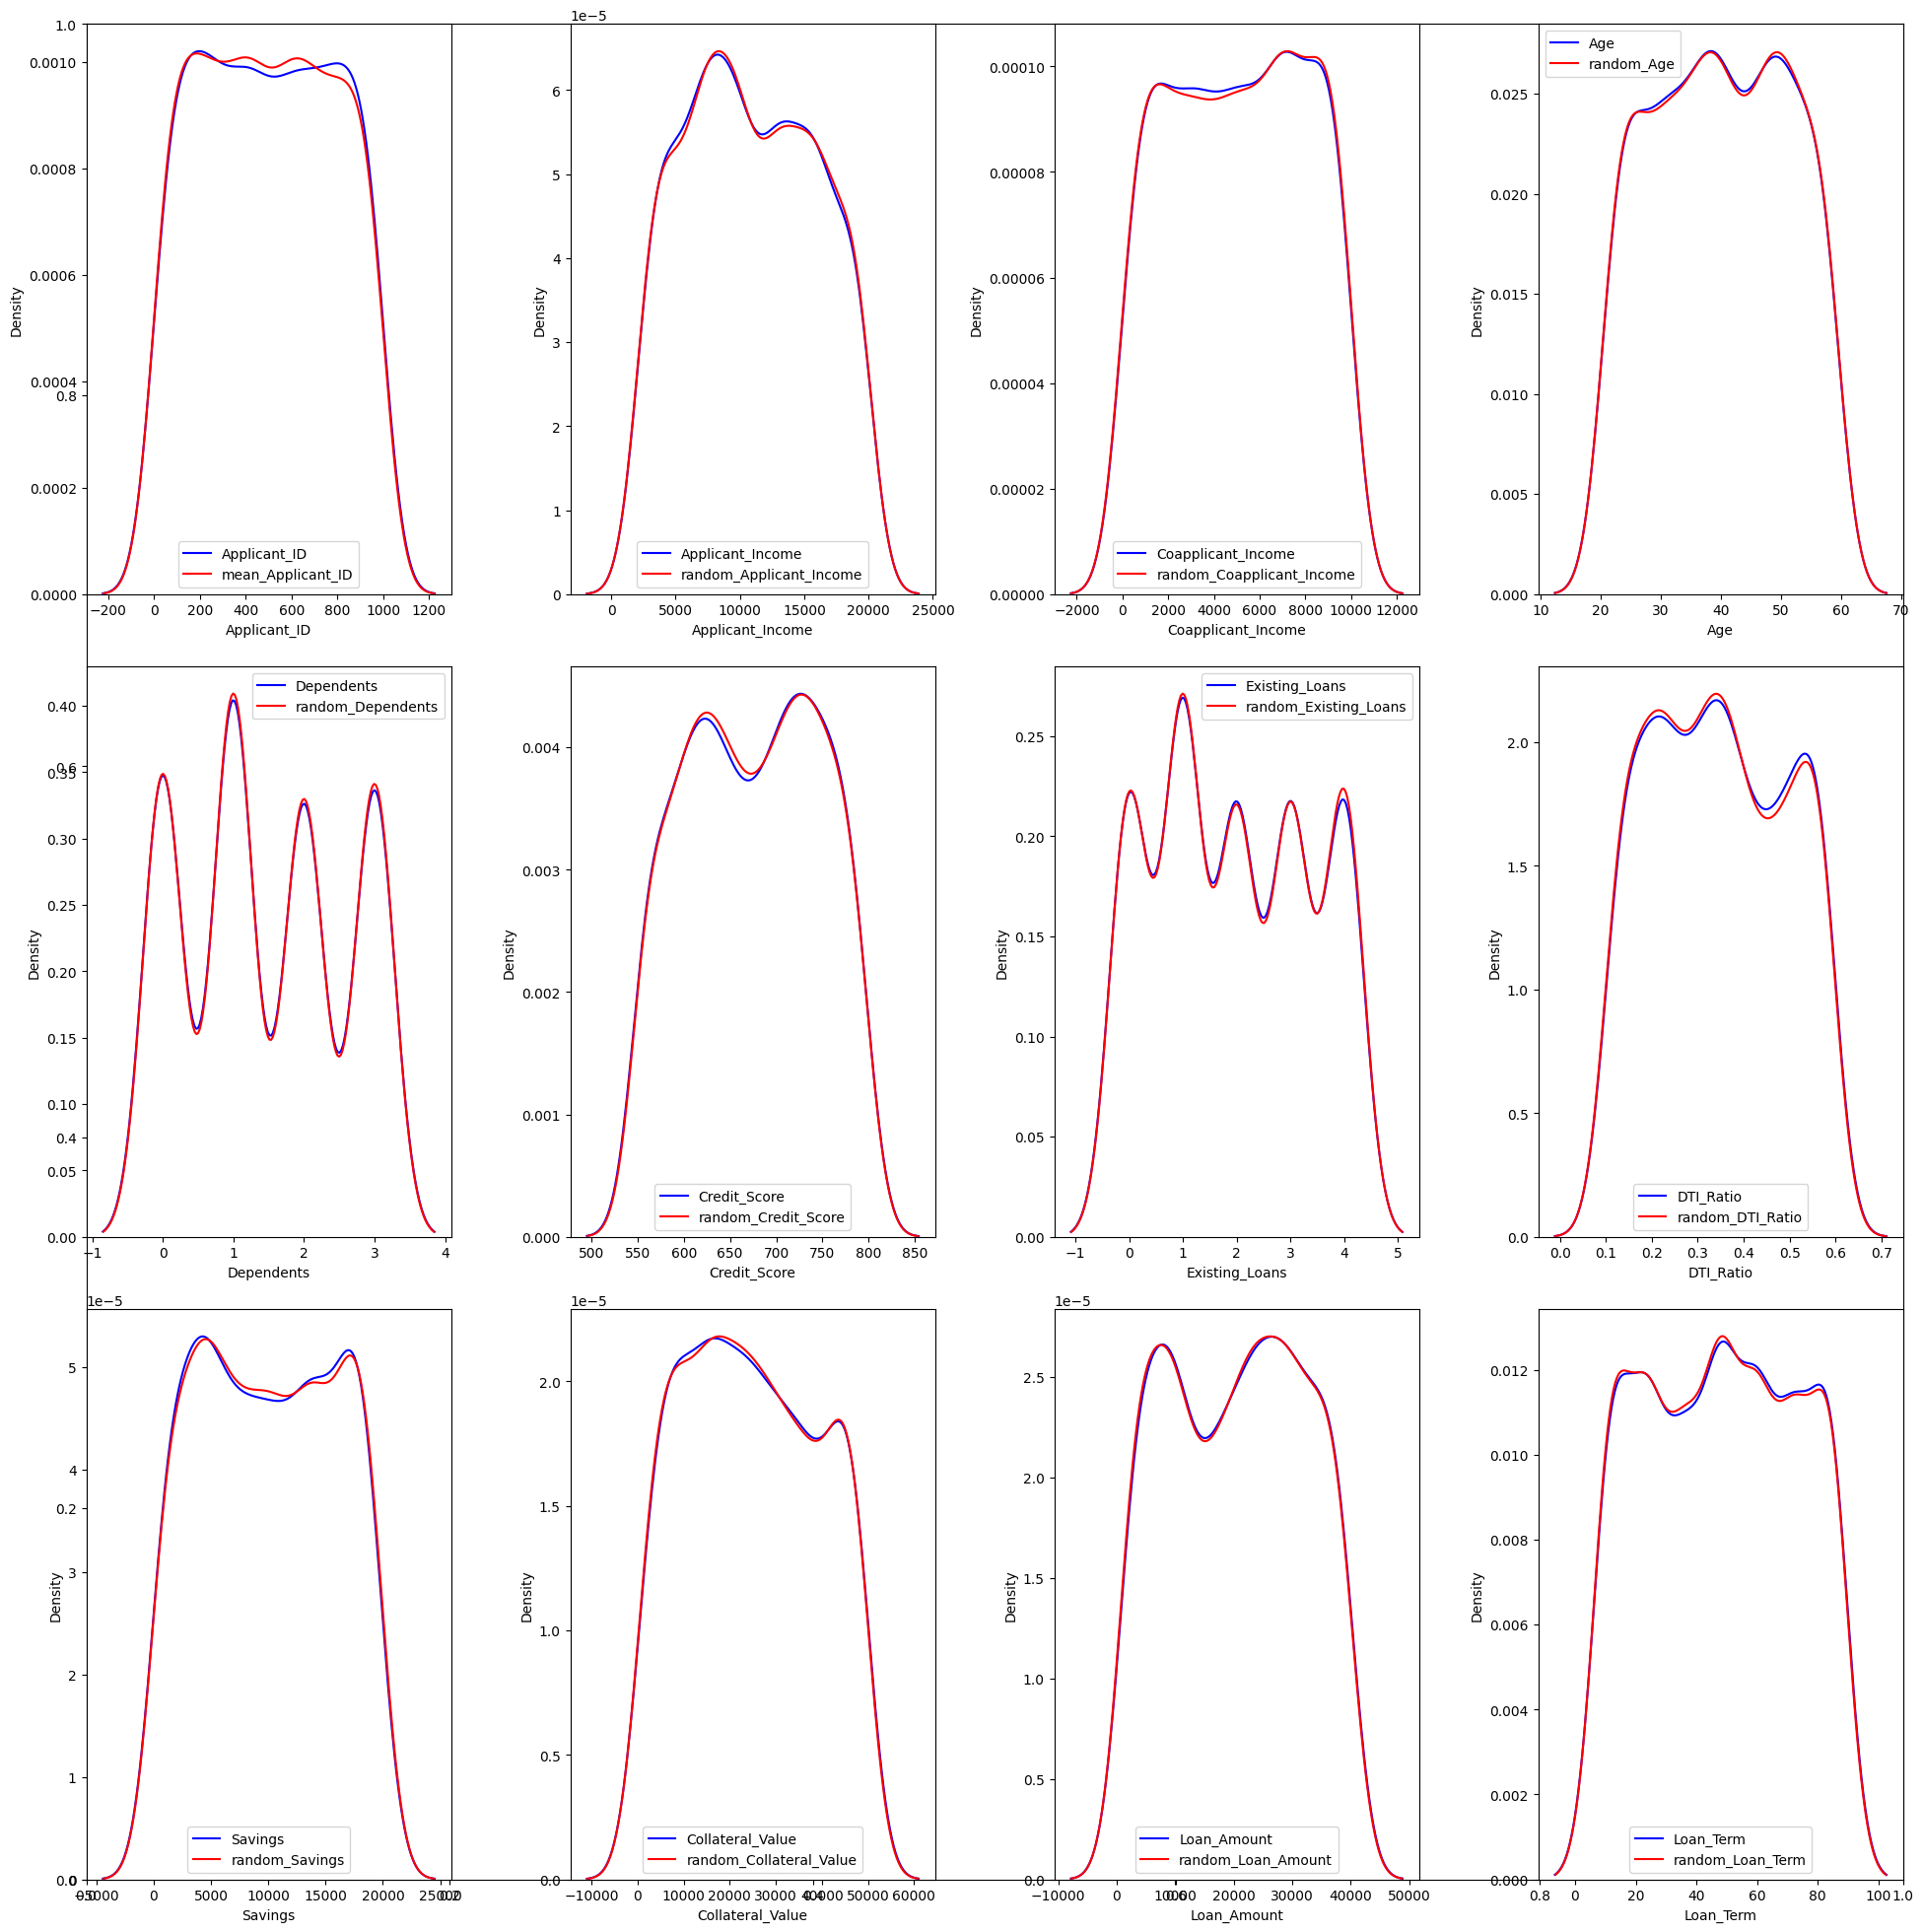

In [869]:
fig , ax = plt.subplots(figsize=(20,20))
plt.subplot(3,4,1)
sns.kdeplot(loan_df["Applicant_ID"],color="blue",label="Applicant_ID")
sns.kdeplot(cpy2_df["Applicant_ID"],color="red",label="mean_Applicant_ID")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,2)
sns.kdeplot(loan_df["Applicant_Income"],color="blue",label="Applicant_Income")
sns.kdeplot(cpy2_df["Applicant_Income"],color="red",label="random_Applicant_Income")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,3)
sns.kdeplot(loan_df["Coapplicant_Income"],color="blue",label="Coapplicant_Income")
sns.kdeplot(cpy2_df["Coapplicant_Income"],color="red",label="random_Coapplicant_Income")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,4)
sns.kdeplot(loan_df["Age"],color="blue",label="Age")
sns.kdeplot(cpy2_df["Age"],color="red",label="random_Age")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,5)
sns.kdeplot(loan_df["Dependents"],color="blue",label="Dependents")
sns.kdeplot(cpy2_df["Dependents"],color="red",label="random_Dependents")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,6)
sns.kdeplot(loan_df["Credit_Score"],color="blue",label="Credit_Score")
sns.kdeplot(cpy2_df["Credit_Score"],color="red",label="random_Credit_Score")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,7)
sns.kdeplot(loan_df["Existing_Loans"],color="blue",label="Existing_Loans")
sns.kdeplot(cpy2_df["Existing_Loans"],color="red",label="random_Existing_Loans")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,8)
sns.kdeplot(loan_df["DTI_Ratio"],color="blue",label="DTI_Ratio")
sns.kdeplot(cpy2_df["DTI_Ratio"],color="red",label="random_DTI_Ratio")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,9)
sns.kdeplot(loan_df["Savings"],color="blue",label="Savings")
sns.kdeplot(cpy2_df["Savings"],color="red",label="random_Savings")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,10)
sns.kdeplot(loan_df["Collateral_Value"],color="blue",label="Collateral_Value")
sns.kdeplot(cpy2_df["Collateral_Value"],color="red",label="random_Collateral_Value")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,11)
sns.kdeplot(loan_df["Loan_Amount"],color="blue",label="Loan_Amount")
sns.kdeplot(cpy2_df["Loan_Amount"],color="red",label="random_Loan_Amount")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,12)
sns.kdeplot(loan_df["Loan_Term"],color="blue",label="Loan_Term")
sns.kdeplot(cpy2_df["Loan_Term"],color="red",label="random_Loan_Term")
plt.tight_layout()
plt.legend()

plt.show()


In [870]:
cpy3_df = loan_df.copy()

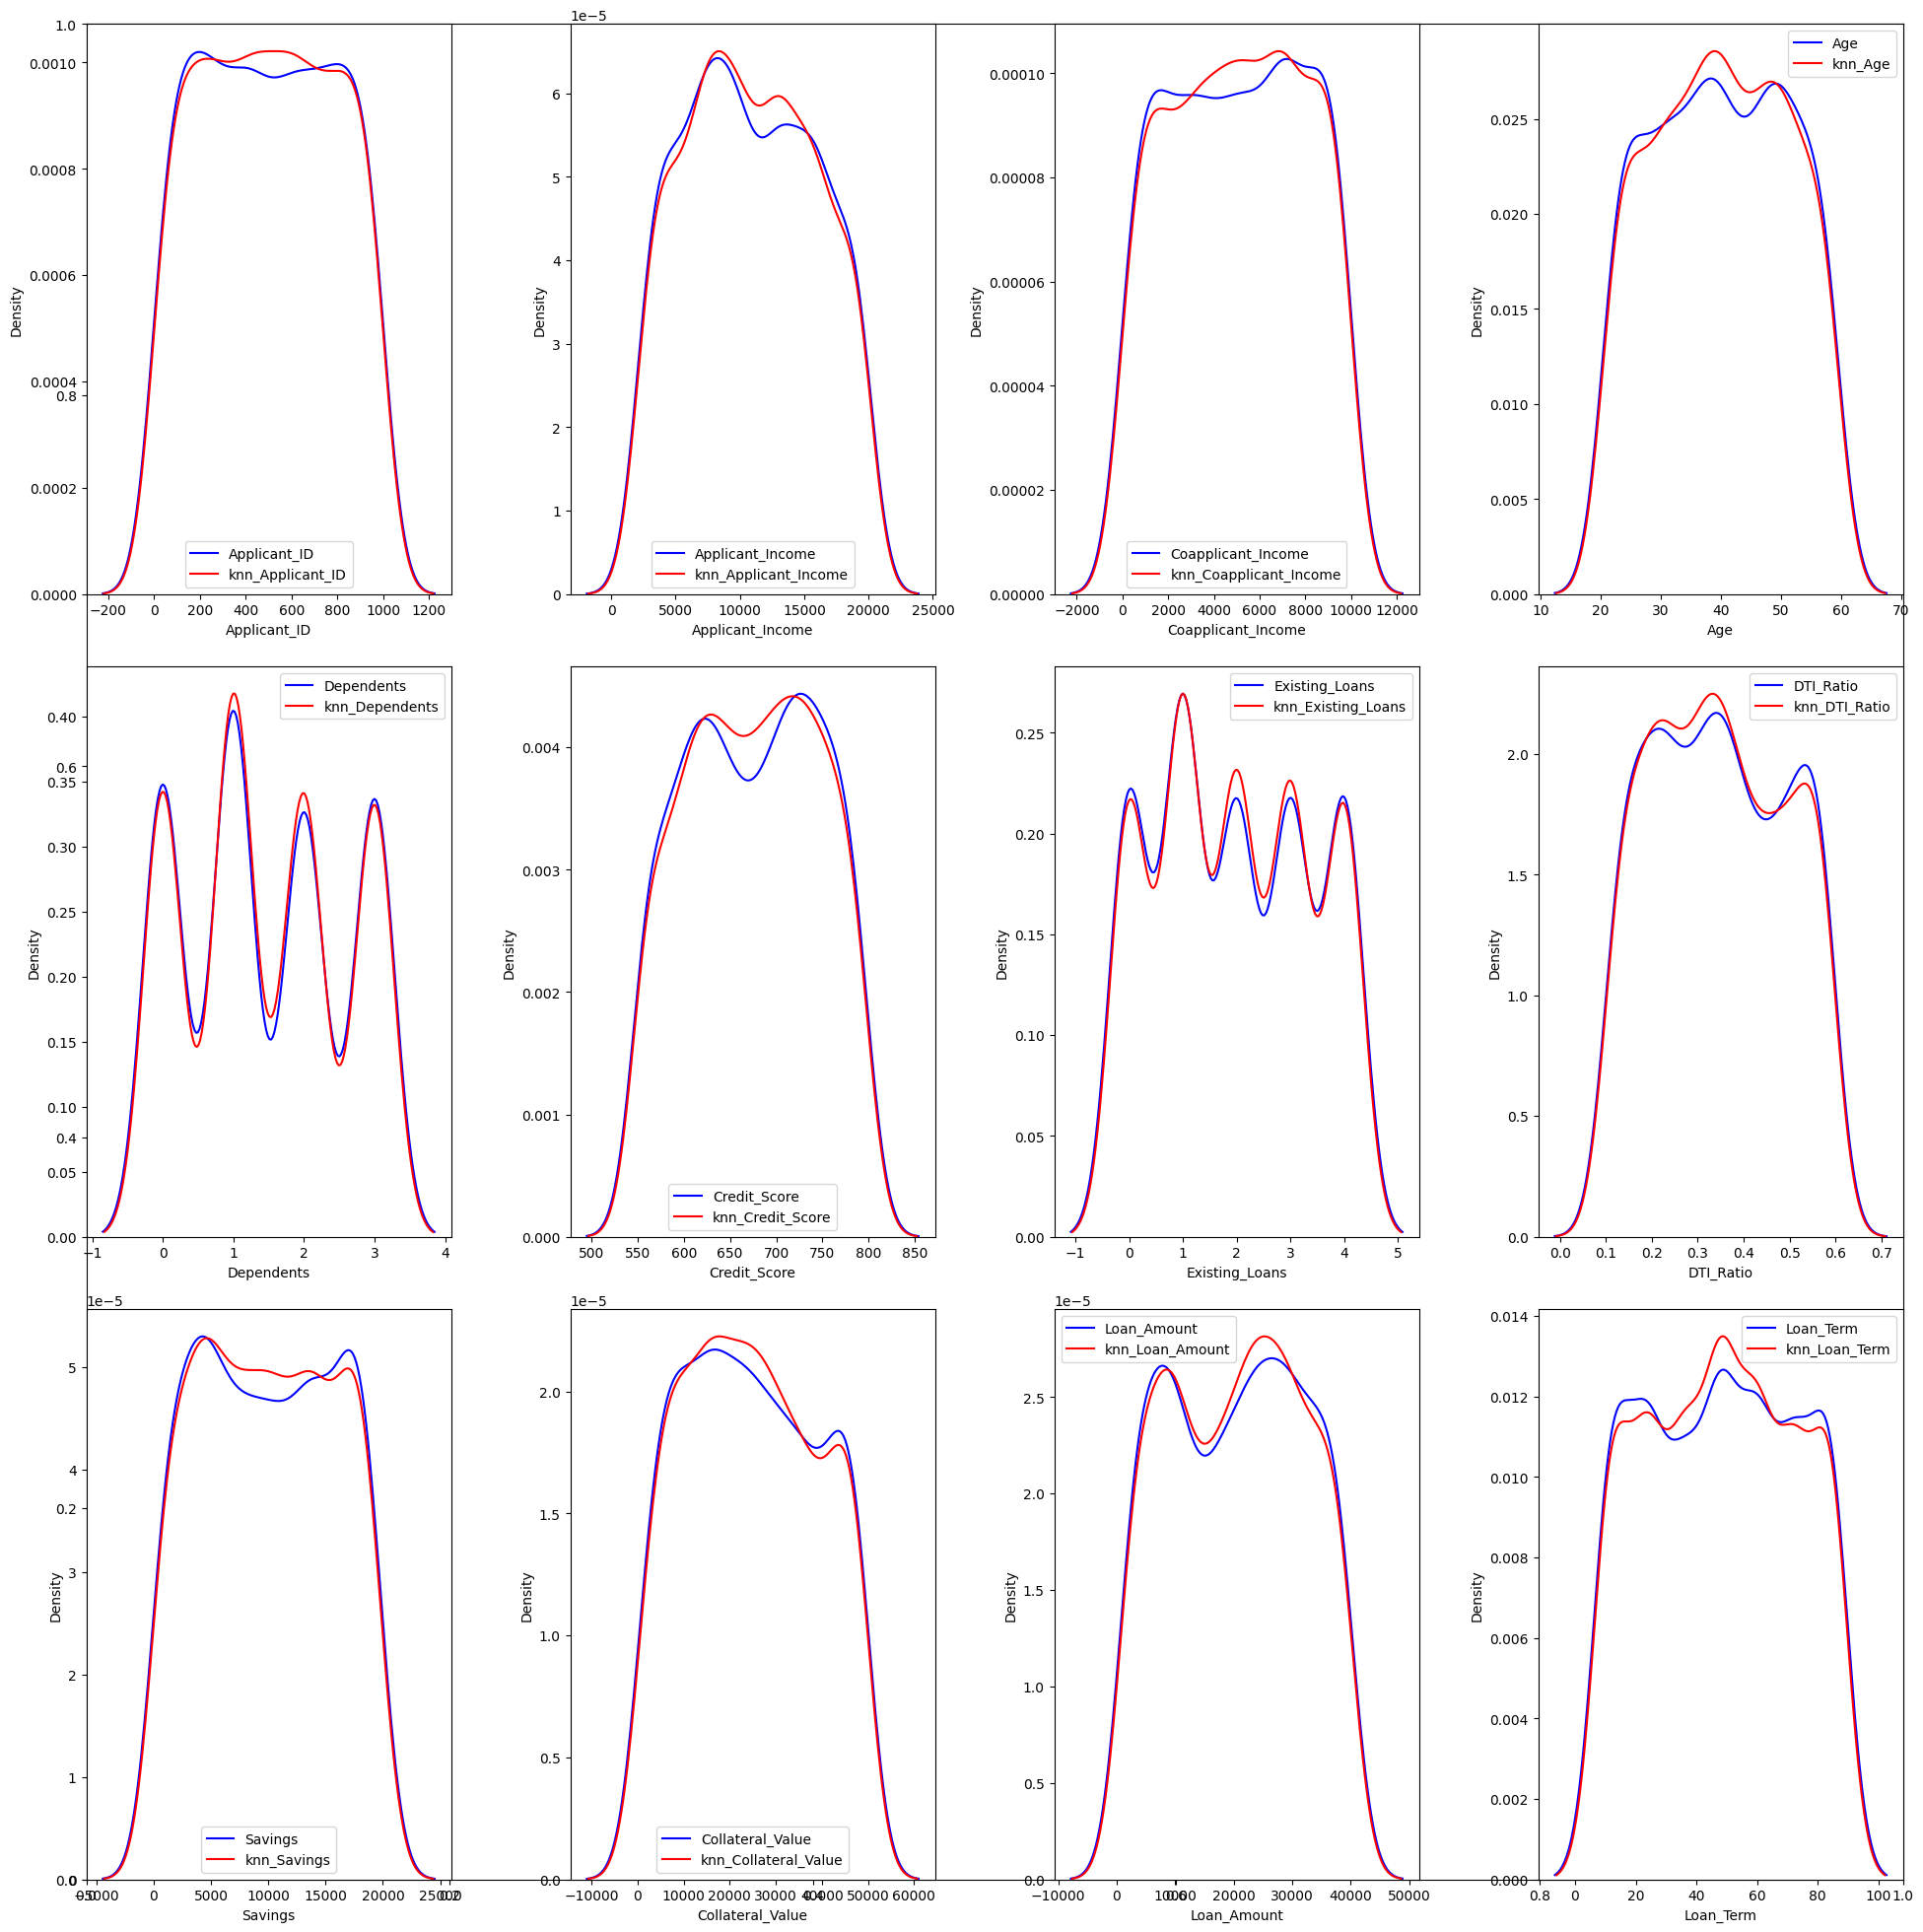

In [871]:
#KNN IMPUTER
knn = KNNImputer(n_neighbors=3)
cpy3_df[numeric_cols] = knn.fit_transform(cpy3_df[numeric_cols])

fig , ax = plt.subplots(figsize=(20,20))
plt.subplot(3,4,1)
sns.kdeplot(loan_df["Applicant_ID"],color="blue",label="Applicant_ID")
sns.kdeplot(cpy3_df["Applicant_ID"],color="red",label="knn_Applicant_ID")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,2)
sns.kdeplot(loan_df["Applicant_Income"],color="blue",label="Applicant_Income")
sns.kdeplot(cpy3_df["Applicant_Income"],color="red",label="knn_Applicant_Income")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,3)
sns.kdeplot(loan_df["Coapplicant_Income"],color="blue",label="Coapplicant_Income")
sns.kdeplot(cpy3_df["Coapplicant_Income"],color="red",label="knn_Coapplicant_Income")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,4)
sns.kdeplot(loan_df["Age"],color="blue",label="Age")
sns.kdeplot(cpy3_df["Age"],color="red",label="knn_Age")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,5)
sns.kdeplot(loan_df["Dependents"],color="blue",label="Dependents")
sns.kdeplot(cpy3_df["Dependents"],color="red",label="knn_Dependents")
plt.tight_layout()
plt.legend()

plt.subplot(3,4,6)
sns.kdeplot(loan_df["Credit_Score"],color="blue",label="Credit_Score")
sns.kdeplot(cpy3_df["Credit_Score"],color="red",label="knn_Credit_Score")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,7)
sns.kdeplot(loan_df["Existing_Loans"],color="blue",label="Existing_Loans")
sns.kdeplot(cpy3_df["Existing_Loans"],color="red",label="knn_Existing_Loans")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,8)
sns.kdeplot(loan_df["DTI_Ratio"],color="blue",label="DTI_Ratio")
sns.kdeplot(cpy3_df["DTI_Ratio"],color="red",label="knn_DTI_Ratio")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,9)
sns.kdeplot(loan_df["Savings"],color="blue",label="Savings")
sns.kdeplot(cpy3_df["Savings"],color="red",label="knn_Savings")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,10)
sns.kdeplot(loan_df["Collateral_Value"],color="blue",label="Collateral_Value")
sns.kdeplot(cpy3_df["Collateral_Value"],color="red",label="knn_Collateral_Value")
plt.tight_layout()
plt.legend()



plt.subplot(3,4,11)
sns.kdeplot(loan_df["Loan_Amount"],color="blue",label="Loan_Amount")
sns.kdeplot(cpy3_df["Loan_Amount"],color="red",label="knn_Loan_Amount")
plt.tight_layout()
plt.legend()


plt.subplot(3,4,12)
sns.kdeplot(loan_df["Loan_Term"],color="blue",label="Loan_Term")
sns.kdeplot(cpy3_df["Loan_Term"],color="red",label="knn_Loan_Term")
plt.tight_layout()
plt.legend()

plt.show()

INPUT CATEGORICAL COLUMNS HANDLING MISSING VALUES

In [872]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='object')

In [873]:
cpy4_df = loan_df.copy()

In [874]:
si = SimpleImputer(strategy="most_frequent")
cpy4_df[categorical_cols] = si.fit_transform(cpy4_df[categorical_cols])



HANDLED MISSING  VALUES IN NUMERICAL AND CATEGORICAL COLUMN

NOW GOING TO MAKE CHANGE IN ORIGINAL loan_df -
in numeircal - random impuation
in categorical - most frequent imputation

In [875]:
#Random Impuation in Numerical column
loan_df.loc[loan_df["Applicant_ID"].isnull(),"Applicant_ID"] = loan_df["Applicant_ID"].dropna().sample(loan_df["Applicant_ID"].isnull().sum()).values
loan_df.loc[loan_df["Applicant_Income"].isnull(),"Applicant_Income"] = loan_df["Applicant_Income"].dropna().sample(loan_df["Applicant_Income"].isnull().sum()).values
loan_df.loc[loan_df["Coapplicant_Income"].isnull(),"Coapplicant_Income"] = loan_df["Coapplicant_Income"].dropna().sample(loan_df["Coapplicant_Income"].isnull().sum()).values
loan_df.loc[loan_df["Age"].isnull(),"Age"] = loan_df["Age"].dropna().sample(loan_df["Age"].isnull().sum()).values
loan_df.loc[loan_df["Dependents"].isnull(),"Dependents"] = loan_df["Dependents"].dropna().sample(loan_df["Dependents"].isnull().sum()).values
loan_df.loc[loan_df["Credit_Score"].isnull(),"Credit_Score"] = loan_df["Credit_Score"].dropna().sample(loan_df["Credit_Score"].isnull().sum()).values
loan_df.loc[loan_df["Existing_Loans"].isnull(),"Existing_Loans"] = loan_df["Existing_Loans"].dropna().sample(loan_df["Existing_Loans"].isnull().sum()).values
loan_df.loc[loan_df["DTI_Ratio"].isnull(),"DTI_Ratio"] = loan_df["DTI_Ratio"].dropna().sample(loan_df["DTI_Ratio"].isnull().sum()).values
loan_df.loc[loan_df["Savings"].isnull(),"Savings"] = loan_df["Savings"].dropna().sample(loan_df["Savings"].isnull().sum()).values
loan_df.loc[loan_df["Collateral_Value"].isnull(),"Collateral_Value"] = loan_df["Collateral_Value"].dropna().sample(loan_df["Collateral_Value"].isnull().sum()).values
loan_df.loc[loan_df["Loan_Amount"].isnull(),"Loan_Amount"] = loan_df["Loan_Amount"].dropna().sample(loan_df["Loan_Amount"].isnull().sum()).values
loan_df.loc[loan_df["Loan_Term"].isnull(),"Loan_Term"] = loan_df["Loan_Term"].dropna().sample(loan_df["Loan_Term"].isnull().sum()).values




In [876]:
# MOST FREQUENT IMPUTER IN CATEGORICAL COLUMNS
si = SimpleImputer(strategy="most_frequent")
loan_df[categorical_cols] = si.fit_transform(loan_df[categorical_cols])

In [877]:
loan_df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


## EDA - EXPLORATRY DATA ANALYSIS

In [878]:
loan_df.shape

(950, 20)

In [879]:
loan_df.sample(5)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
11,12.0,10322.0,8428.0,Self-employed,41.0,Married,1.0,743.0,4.0,0.23,2970.0,38333.0,12085.0,84.0,Car,Semiurban,Graduate,Male,Government,1
254,261.0,14468.0,4133.0,Contract,54.0,Married,0.0,708.0,1.0,0.22,6684.0,18812.0,38116.0,72.0,Personal,Urban,Graduate,Male,Private,1
498,524.0,11337.0,6295.0,Salaried,29.0,Single,1.0,558.0,0.0,0.34,569.0,47723.0,26669.0,36.0,Education,Urban,Graduate,Male,Private,0
662,694.0,6632.0,5592.0,Self-employed,31.0,Married,0.0,725.0,2.0,0.13,17700.0,44331.0,10481.0,48.0,Education,Urban,Graduate,Male,Private,1
282,290.0,7801.0,362.0,Salaried,34.0,Married,3.0,663.0,0.0,0.47,13055.0,24174.0,36185.0,24.0,Business,Urban,Graduate,Male,Business,0


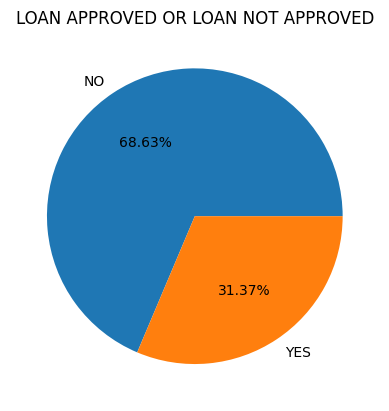

In [880]:
#classes_count
classes_count = loan_df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["NO","YES"],autopct="%1.2f%%")
plt.title("LOAN APPROVED OR LOAN NOT APPROVED")
plt.show()


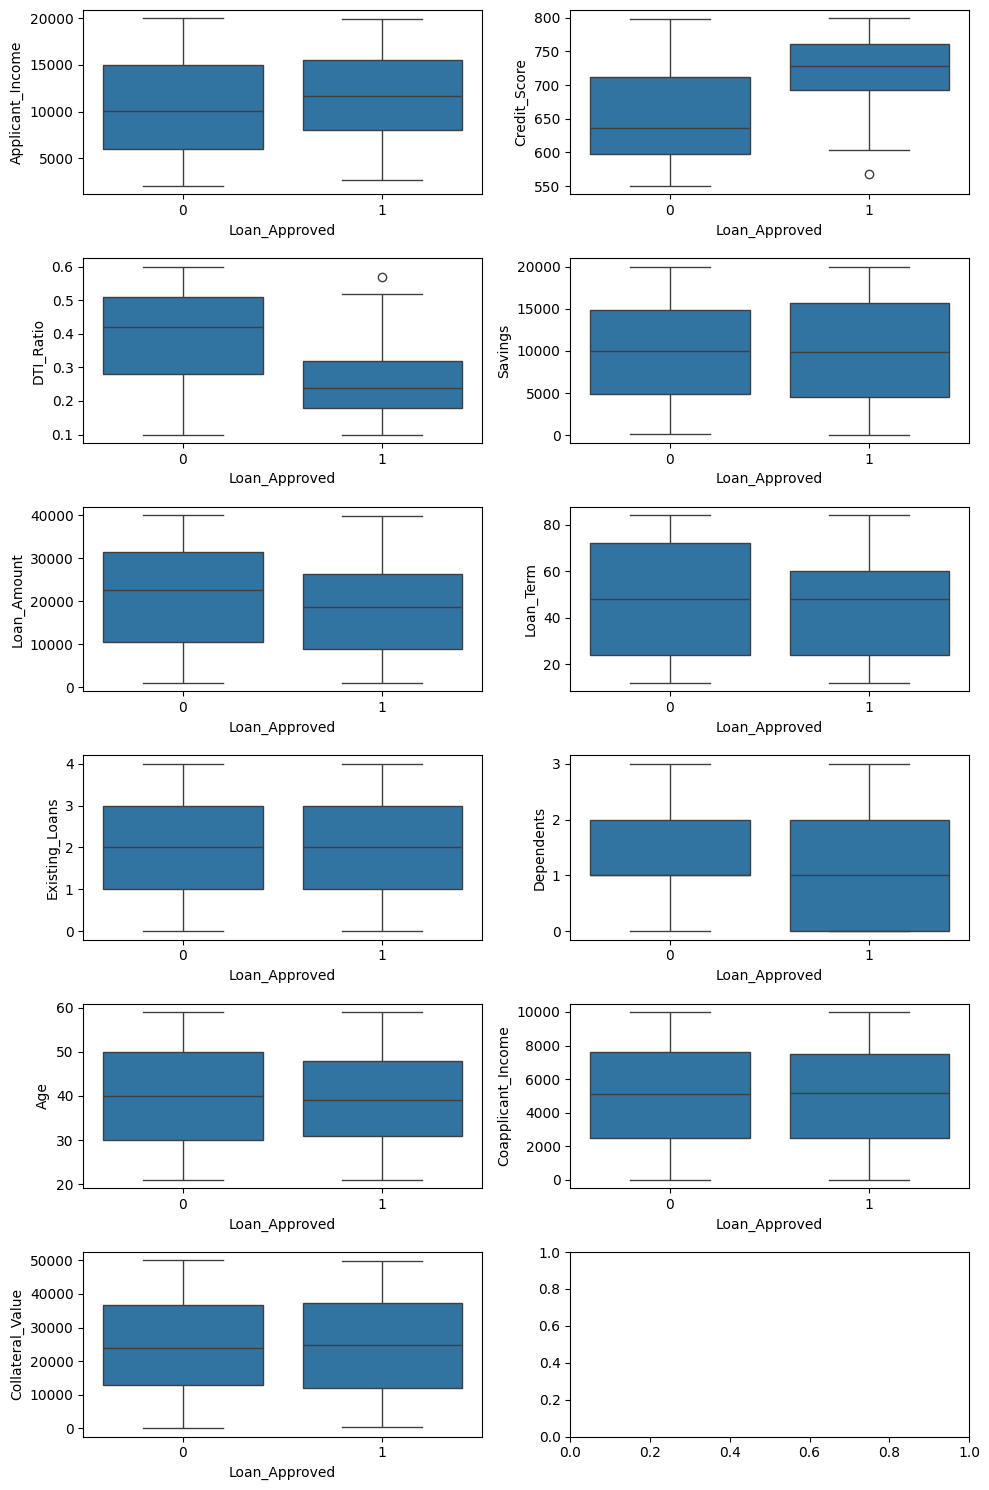

In [881]:
#check for outlier
fig , ax  = plt.subplots(6,2,figsize=(10,15))
sns.boxplot(ax = ax[0][0],data = loan_df ,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = ax[0][1],data = loan_df ,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = ax[1][0],data = loan_df ,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = ax[1][1],data = loan_df ,x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = ax[2][0],data = loan_df ,x = "Loan_Approved",y = "Loan_Amount")
sns.boxplot(ax = ax[2][1],data = loan_df ,x = "Loan_Approved",y = "Loan_Term")
sns.boxplot(ax = ax[3][0],data = loan_df ,x = "Loan_Approved",y = "Existing_Loans")
sns.boxplot(ax = ax[3][1],data = loan_df ,x = "Loan_Approved",y = "Dependents")
sns.boxplot(ax = ax[4][0],data = loan_df ,x = "Loan_Approved",y = "Age")
sns.boxplot(ax = ax[4][1],data = loan_df ,x = "Loan_Approved",y = "Coapplicant_Income")
sns.boxplot(ax = ax[5][0],data = loan_df ,x = "Loan_Approved",y = "Collateral_Value")

plt.tight_layout()
plt.show()

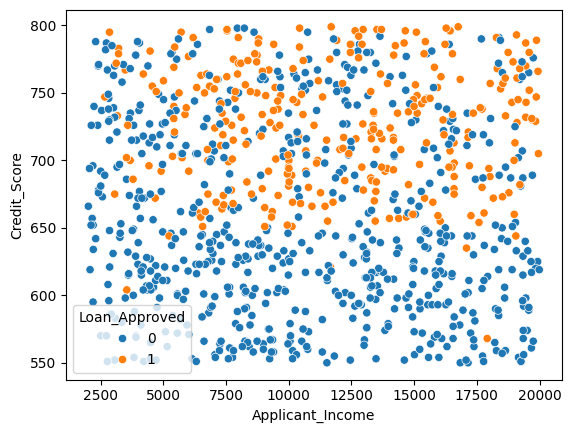

In [882]:
sns.scatterplot(data = loan_df,x = "Applicant_Income",y = "Credit_Score",hue = "Loan_Approved")


plt.show()

<Axes: xlabel='Applicant_Income', ylabel='DTI_Ratio'>

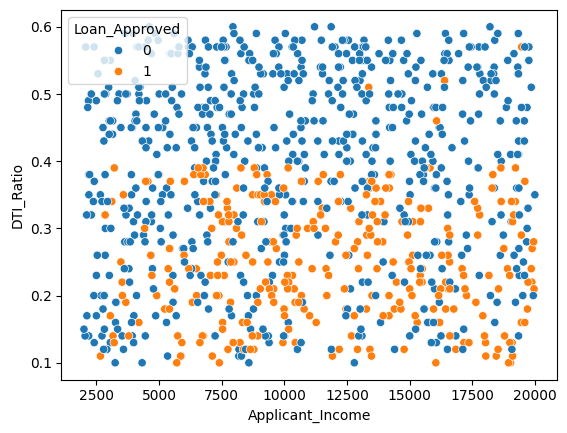

In [883]:
sns.scatterplot(data = loan_df,x = "Applicant_Income",y = "DTI_Ratio",hue = "Loan_Approved")

In [884]:
#HANDLING OUTLIERS  - IN CREDIT SCORE in categories 1
Q3   = loan_df["Credit_Score"][loan_df["Loan_Approved"]==1].quantile(0.75)
Q1   = loan_df["Credit_Score"][loan_df["Loan_Approved"]==1].quantile(0.25)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [885]:
loan_df.loc[(loan_df["Loan_Approved"] == 1) & ((loan_df["Credit_Score"] > upper_limit) | (loan_df["Credit_Score"] < lower_limit))]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
675,710.0,17913.0,4399.0,Salaried,21.0,Single,2.0,568.0,0.0,0.17,6554.0,38665.0,14697.0,48.0,Personal,Semiurban,Graduate,Male,Private,1


In [886]:
loan_df.loc[(loan_df["Loan_Approved"]==1) & (loan_df["Credit_Score"]>upper_limit)|(loan_df["Credit_Score"]<lower_limit),"Loan_Approved"] = 0

<Axes: xlabel='Loan_Approved', ylabel='Credit_Score'>

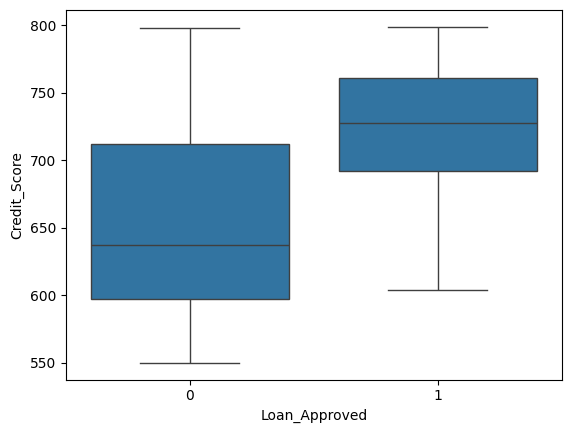

In [887]:
sns.boxplot(data= loan_df , x ="Loan_Approved", y = "Credit_Score")

<Axes: xlabel='Applicant_Income', ylabel='Credit_Score'>

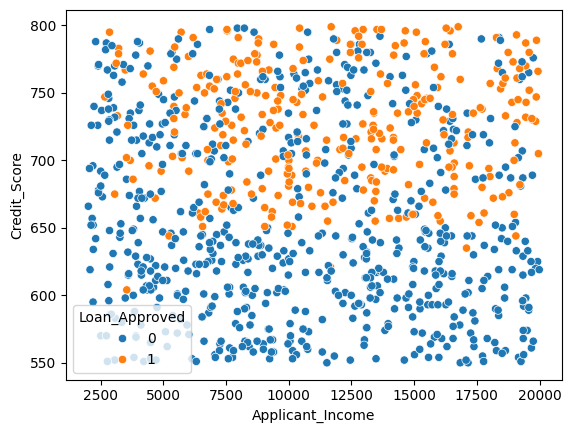

In [888]:
sns.scatterplot(data = loan_df,x = "Applicant_Income",y = "Credit_Score",hue = "Loan_Approved")

In [889]:
#HANDLING OUTLIERS  - IN DTI_RATIO in categories 1

Q3   = loan_df["DTI_Ratio"][loan_df["Loan_Approved"]==1].quantile(0.75)
Q1   = loan_df["DTI_Ratio"][loan_df["Loan_Approved"]==1].quantile(0.25)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [890]:
loan_df.loc[(loan_df["Loan_Approved"] == 1) & ((loan_df["DTI_Ratio"] > upper_limit) | (loan_df["DTI_Ratio"] < lower_limit))]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
561,589.0,19461.0,9771.0,Contract,37.0,Married,0.0,743.0,1.0,0.57,3573.0,24795.0,33576.0,72.0,Car,Urban,Graduate,Female,Private,1


In [891]:
loan_df.loc[(loan_df["Loan_Approved"] == 1) & (loan_df["DTI_Ratio"] > upper_limit) | (loan_df["DTI_Ratio"] < lower_limit),"Loan_Approved"]=0

In [892]:
loan_df.loc[(loan_df["Loan_Approved"] == 1) & ((loan_df["DTI_Ratio"] > upper_limit) | (loan_df["DTI_Ratio"] < lower_limit))]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved


<Axes: xlabel='Loan_Approved', ylabel='DTI_Ratio'>

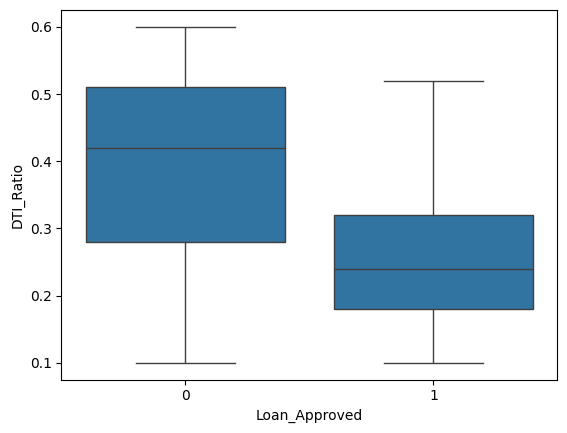

In [893]:
sns.boxplot(data= loan_df , x ="Loan_Approved", y = "DTI_Ratio")

<Axes: xlabel='Applicant_Income', ylabel='DTI_Ratio'>

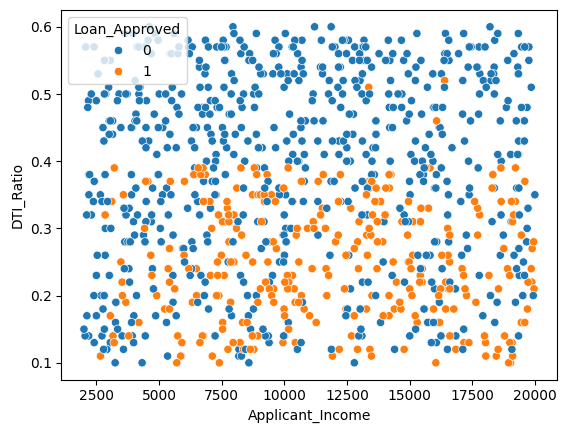

In [894]:
sns.scatterplot(data = loan_df,x = "Applicant_Income",y = "DTI_Ratio",hue = "Loan_Approved")

<Axes: xlabel='Credit_Score', ylabel='Count'>

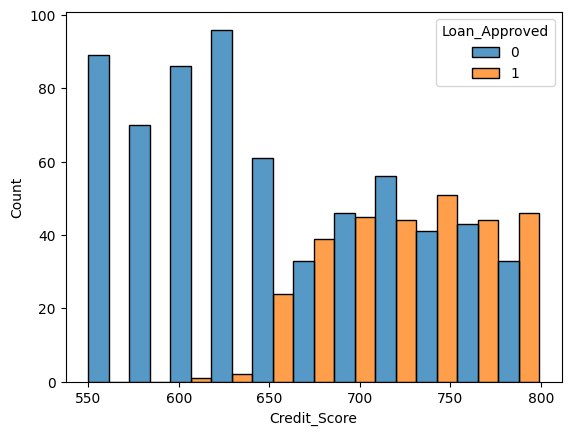

In [895]:
sns.histplot(data = loan_df, x = "Credit_Score",hue = "Loan_Approved",multiple="dodge")

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

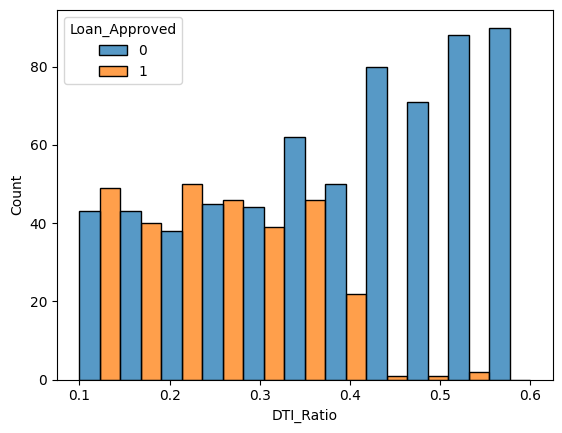

In [896]:
sns.histplot(data = loan_df, x = "DTI_Ratio",hue = "Loan_Approved",multiple="dodge")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

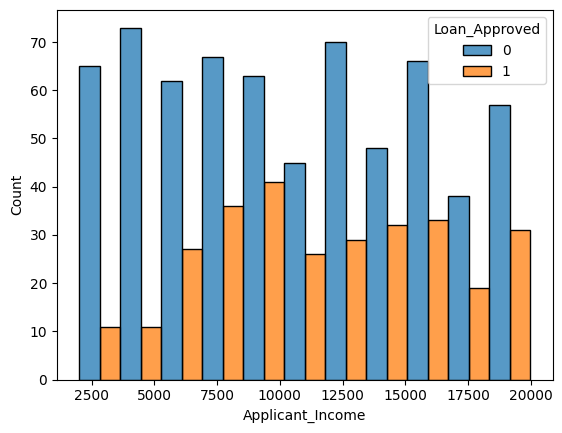

In [897]:
sns.histplot(data = loan_df, x = "Applicant_Income",hue = "Loan_Approved",multiple="dodge")

<Axes: xlabel='Loan_Amount', ylabel='Count'>

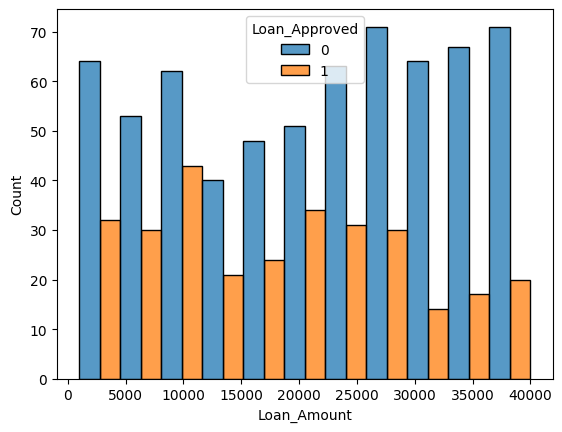

In [898]:
sns.histplot(data = loan_df, x = "Loan_Amount",hue = "Loan_Approved",multiple="dodge")

<Axes: xlabel='Loan_Amount', ylabel='Density'>

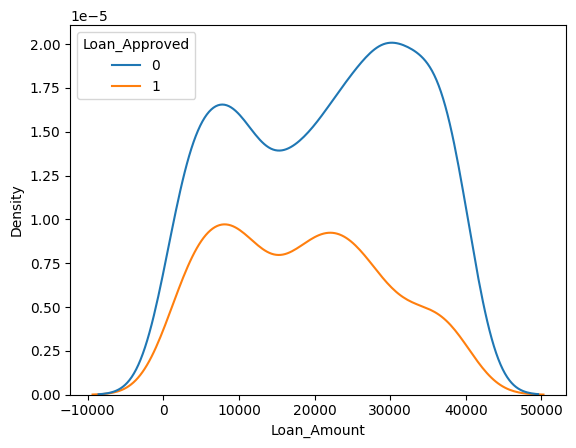

In [899]:
sns.kdeplot(data = loan_df, x = "Loan_Amount",hue = "Loan_Approved")

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

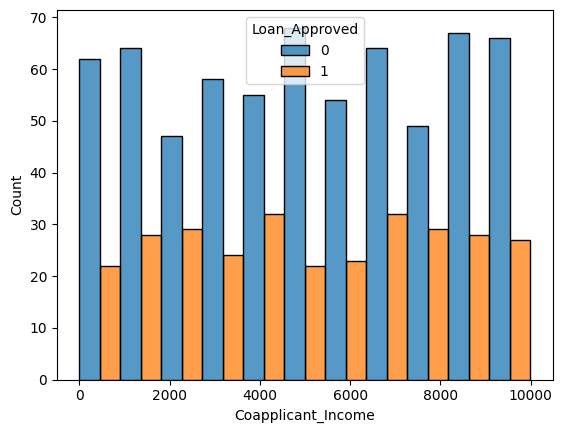

In [900]:
sns.histplot(data = loan_df, x = "Coapplicant_Income",hue = "Loan_Approved",multiple="dodge")

<Axes: xlabel='Loan_Approved', ylabel='count'>

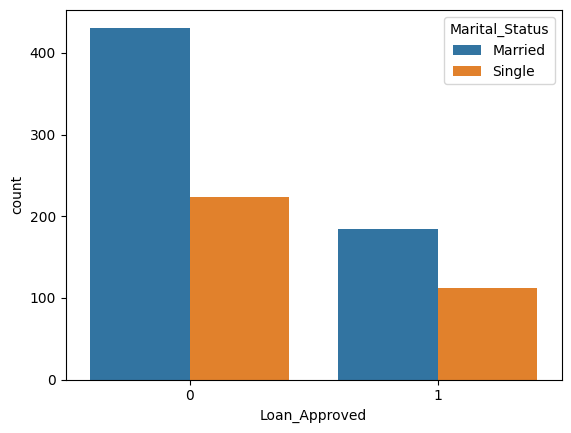

In [901]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Marital_Status")

<Axes: xlabel='Loan_Approved', ylabel='count'>

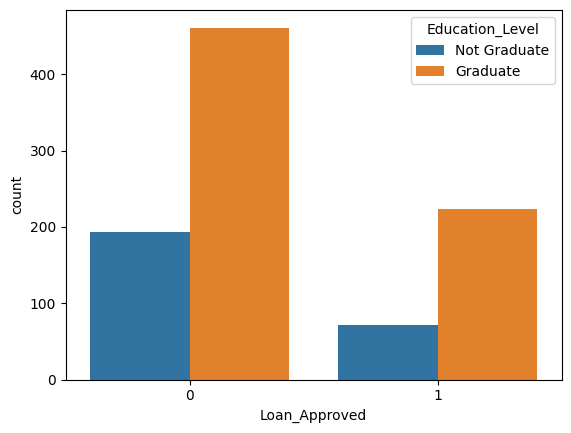

In [902]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Education_Level")

<Axes: xlabel='Loan_Approved', ylabel='count'>

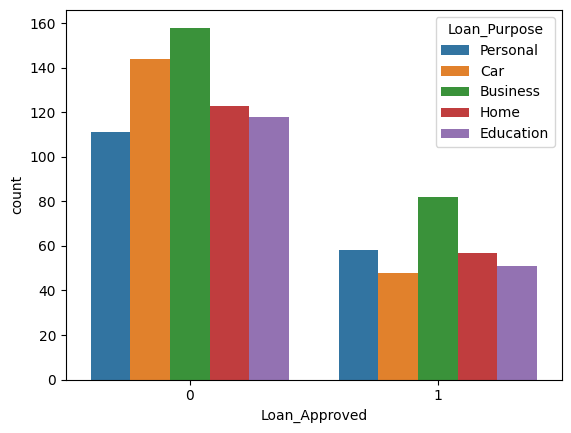

In [903]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Loan_Purpose")

<Axes: xlabel='Loan_Approved', ylabel='count'>

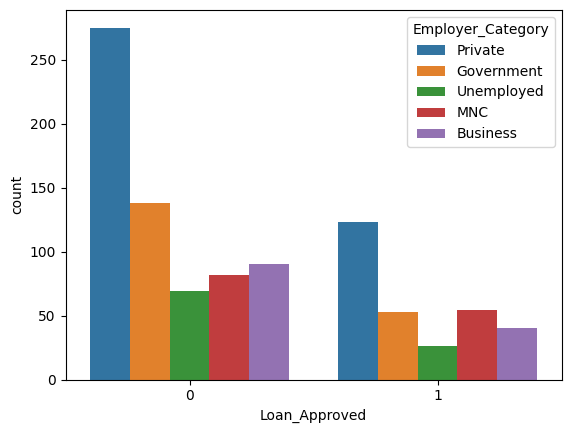

In [904]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Employer_Category")

<Axes: xlabel='Loan_Approved', ylabel='count'>

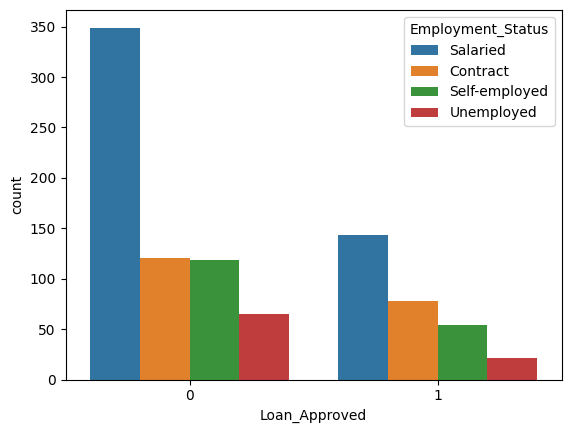

In [905]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Employment_Status")

<Axes: xlabel='Loan_Approved', ylabel='count'>

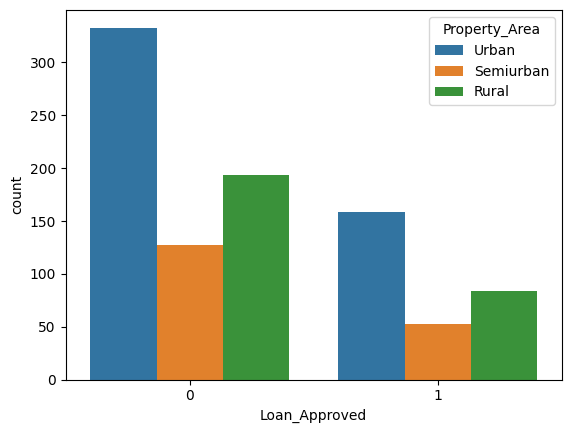

In [906]:
sns.countplot(data = loan_df, x = "Loan_Approved",hue="Property_Area")

In [907]:
loan_df


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,996.0,18509.0,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,0
946,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,12420.0,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,0
947,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,0
948,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,1


In [908]:
#removing applicant_id
loan_df.drop(columns=["Applicant_ID"],inplace=True)

In [909]:
loan_df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,18509.0,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,0
946,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,12420.0,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,0
947,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,0
948,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,1


DONE WITH EDA GETTING INSIGHT -
CREDIT SCORE ABOVE 600 - LOAN APPROVED NOT IN EVERY CASE
DTI_RATIO LESS THAN 5.0 - LOAN APPROVED NOT IN EVERY CASE
BUSINEES LOAN  ARE GETTING MORE LOAN AS COMPARE TO OTHER CATEGORY
DTI,CREDIT SCORE ARE MOST IMPORTANT FEATURE TO PREDICT CLASS
OTHER FEATURE ARE HAVING VERY LOW CO RELATION WITH TARGET.

CO-RELATION HEATMAP

<Axes: >

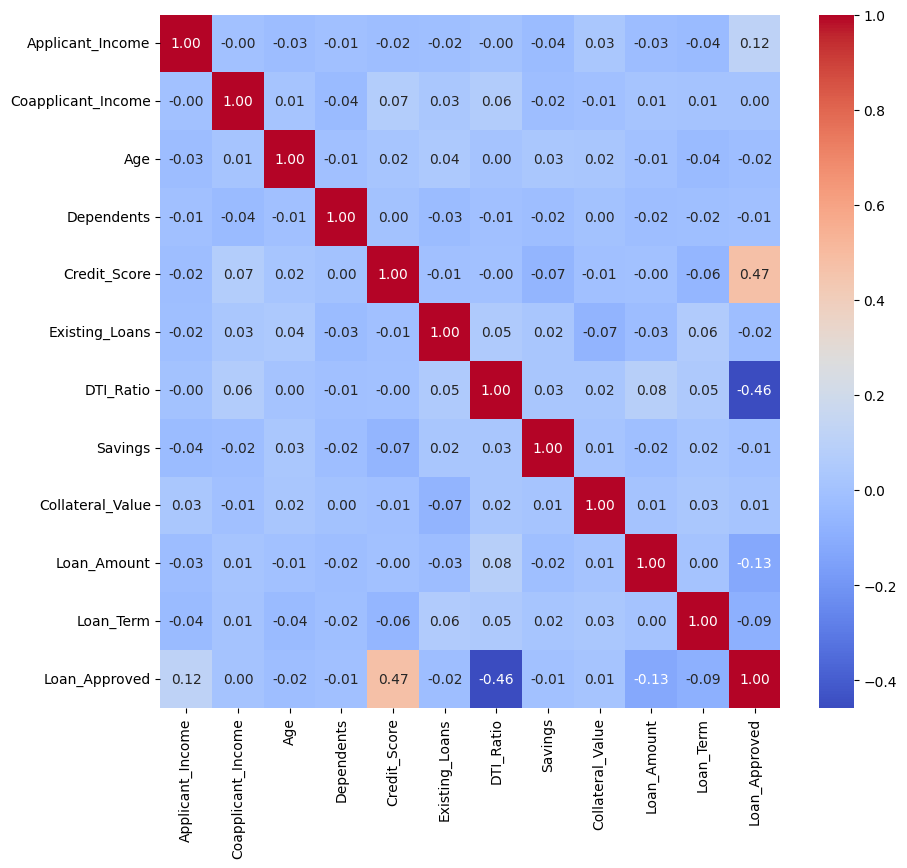

In [910]:
plt.figure(figsize=(10,9))
sns.heatmap(loan_df.corr(numeric_only = True),annot = True,cmap = "coolwarm",fmt=".2f")

In [911]:
column_names = loan_df.columns
column_names

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [912]:
X = loan_df.drop(columns=["Loan_Approved"])
Y = loan_df["Loan_Approved"]

In [913]:
X_train, X_test ,y_train, y_test= train_test_split(X,Y, test_size = 0.2,random_state=42)

In [914]:
X_train

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
936,10705.0,7898.0,Salaried,33.0,Single,1.0,704.0,4.0,0.55,569.0,2654.0,11524.0,84.0,Home,Rural,Graduate,Female,Private
290,10173.0,2808.0,Salaried,25.0,Married,0.0,745.0,3.0,0.22,18055.0,3838.0,22033.0,24.0,Car,Urban,Graduate,Male,Business
544,7997.0,3432.0,Contract,53.0,Single,1.0,750.0,4.0,0.52,598.0,31736.0,25102.0,36.0,Education,Urban,Graduate,Male,Private
275,14249.0,4311.0,Contract,24.0,Single,2.0,785.0,4.0,0.38,2284.0,26754.0,39247.0,48.0,Home,Urban,Graduate,Female,MNC
109,3059.0,1750.0,Salaried,49.0,Married,0.0,770.0,4.0,0.13,15456.0,5067.0,6695.0,72.0,Car,Rural,Graduate,Male,Government
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,9574.0,338.0,Salaried,34.0,Single,2.0,738.0,0.0,0.21,18015.0,6333.0,30489.0,12.0,Education,Rural,Not Graduate,Male,Business
270,13093.0,1591.0,Salaried,36.0,Single,3.0,576.0,2.0,0.14,18657.0,15611.0,3459.0,72.0,Education,Rural,Not Graduate,Female,Business
860,8783.0,7693.0,Contract,40.0,Married,1.0,787.0,3.0,0.12,634.0,9524.0,32510.0,72.0,Business,Urban,Graduate,Male,Private
435,7334.0,7014.0,Unemployed,58.0,Married,1.0,664.0,4.0,0.25,8988.0,43952.0,4909.0,72.0,Business,Urban,Graduate,Male,Business


In [915]:
trf = ColumnTransformer([
    ("ordinal",OrdinalEncoder(categories=[["Not Graduate","Graduate"]]),[15]),
    ("nominal",OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore"),[2,4,13,14,16,17])
],remainder="passthrough")

In [916]:
trf2 = ColumnTransformer([
    ("scale",StandardScaler(),slice(0,27))
])

MODEL TRAINING


In [917]:
#Logistic Regression
pipe_lr = make_pipeline(trf , trf2, LogisticRegression())
pipe_lr.fit(X_train,y_train)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('logisticregression', LogisticRegression())])

In [918]:
y_predict = pipe_lr.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict))
print("recall_score :", recall_score(y_test,y_predict))
print("f1_score :", f1_score(y_test,y_predict))
print("accuracy_score :",accuracy_score(y_test,y_predict))
print("confusion_matrix :",confusion_matrix(y_test,y_predict))

precision_score : 0.8979591836734694
recall_score : 0.7213114754098361
f1_score : 0.8
accuracy_score : 0.8842105263157894
confusion_matrix : [[124   5]
 [ 17  44]]


In [919]:
#KNN
pipe_knn = make_pipeline(trf, trf2, KNeighborsClassifier(n_neighbors=5))
pipe_knn.fit(X_train, y_train)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('kneighborsclassifier', KNeighborsClassifier())])

In [920]:
y_predict2 = pipe_knn.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict2))
print("recall_score :", recall_score(y_test,y_predict2))
print("f1_score :", f1_score(y_test,y_predict2))
print("accuracy_score :",accuracy_score(y_test,y_predict2))
print("confusion_matrix :",confusion_matrix(y_test,y_predict2))

precision_score : 0.6976744186046512
recall_score : 0.4918032786885246
f1_score : 0.5769230769230769
accuracy_score : 0.7684210526315789
confusion_matrix : [[116  13]
 [ 31  30]]


In [921]:
#Naive Bayes
pipe_nb = make_pipeline(trf, trf2, GaussianNB())
pipe_nb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('gaussiannb', GaussianNB())])

In [922]:
y_predict3 = pipe_nb.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict3))
print("recall_score :", recall_score(y_test,y_predict3))
print("f1_score :", f1_score(y_test,y_predict3))
print("accuracy_score :",accuracy_score(y_test,y_predict3))
print("confusion_matrix :",confusion_matrix(y_test,y_predict3))

precision_score : 0.8958333333333334
recall_score : 0.7049180327868853
f1_score : 0.7889908256880734
accuracy_score : 0.8789473684210526
confusion_matrix : [[124   5]
 [ 18  43]]


In [923]:
#Feature Engineering to improve model performance
#loan_df.drop(columns=["Marital_Status"],inplace=True)
loan_df["Credit_Score"] = loan_df["Credit_Score"]**2
loan_df["DTI_Ratio"] = loan_df["DTI_Ratio"]**2


In [924]:
X = loan_df.drop(columns=["Loan_Approved"])
Y = loan_df["Loan_Approved"]

In [925]:
X_train, X_test ,y_train, y_test= train_test_split(X,Y, test_size = 0.2,random_state=42)

In [926]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760 entries, 936 to 102
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    760 non-null    float64
 1   Coapplicant_Income  760 non-null    float64
 2   Employment_Status   760 non-null    object 
 3   Age                 760 non-null    float64
 4   Marital_Status      760 non-null    object 
 5   Dependents          760 non-null    float64
 6   Credit_Score        760 non-null    float64
 7   Existing_Loans      760 non-null    float64
 8   DTI_Ratio           760 non-null    float64
 9   Savings             760 non-null    float64
 10  Collateral_Value    760 non-null    float64
 11  Loan_Amount         760 non-null    float64
 12  Loan_Term           760 non-null    float64
 13  Loan_Purpose        760 non-null    object 
 14  Property_Area       760 non-null    object 
 15  Education_Level     760 non-null    object 
 16  Gender     

In [927]:
trf = ColumnTransformer([
    ("ordinal",OrdinalEncoder(categories=[["Not Graduate","Graduate"]]),[15]),
    ("nominal",OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore"),[2,4,13,14,16,17])
],remainder="passthrough")

In [928]:
trf2 = ColumnTransformer([
    ("scale",StandardScaler(),slice(0,27))
])

In [929]:
#Logistic Regression
pipe_lr = make_pipeline(trf , trf2, LogisticRegression())
pipe_lr.fit(X_train,y_train)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('logisticregression', LogisticRegression())])

In [930]:
y_predict = pipe_lr.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict))
print("recall_score :", recall_score(y_test,y_predict))
print("f1_score :", f1_score(y_test,y_predict))
print("accuracy_score :",accuracy_score(y_test,y_predict))
print("confusion_matrix :",confusion_matrix(y_test,y_predict))

precision_score : 0.8727272727272727
recall_score : 0.7868852459016393
f1_score : 0.8275862068965517
accuracy_score : 0.8947368421052632
confusion_matrix : [[122   7]
 [ 13  48]]


In [931]:
#KNN
pipe_knn = make_pipeline(trf, trf2, KNeighborsClassifier(n_neighbors=5))
pipe_knn.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('kneighborsclassifier', KNeighborsClassifier())])

In [932]:
y_predict2 = pipe_knn.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict2))
print("recall_score :", recall_score(y_test,y_predict2))
print("f1_score :", f1_score(y_test,y_predict2))
print("accuracy_score :",accuracy_score(y_test,y_predict2))
print("confusion_matrix :",confusion_matrix(y_test,y_predict2))

precision_score : 0.6956521739130435
recall_score : 0.5245901639344263
f1_score : 0.5981308411214953
accuracy_score : 0.7736842105263158
confusion_matrix : [[115  14]
 [ 29  32]]


In [933]:
#gaussiannaviebayes
pipe_nb = make_pipeline(trf, trf2, GaussianNB())
pipe_nb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Not '
                                                                              'Graduate',
                                                                              'Graduate']]),
                                                  [15]),
                                                 ('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [2, 4, 13, 14, 16, 17])])),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  slice(0, 27, None))])),
                ('gaussiannb', GaussianNB())])

In [934]:
y_predict3 = pipe_nb.predict(X_test)
print("precision_score :", precision_score(y_test,y_predict3))
print("recall_score :", recall_score(y_test,y_predict3))
print("f1_score :", f1_score(y_test,y_predict3))
print("accuracy_score :",accuracy_score(y_test,y_predict3))
print("confusion_matrix :",confusion_matrix(y_test,y_predict3))

precision_score : 0.8846153846153846
recall_score : 0.7540983606557377
f1_score : 0.8141592920353983
accuracy_score : 0.8894736842105263
confusion_matrix : [[123   6]
 [ 15  46]]


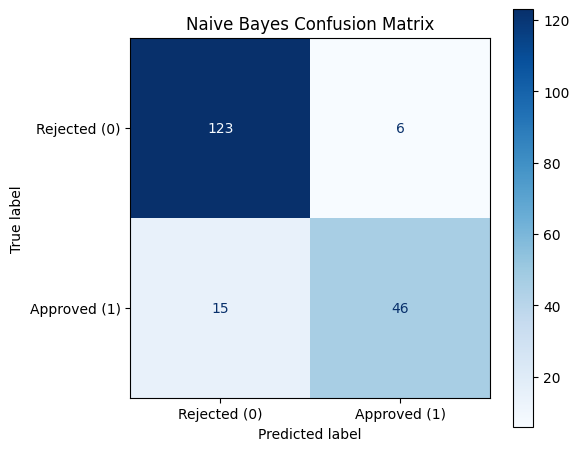

In [935]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_predict3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected (0)', 'Approved (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()

OUR TWO  CHALLENGES  WAS -  1. GOOD CUSTOMER DO NOT GET REJECTED
                            2. HIGH - RISK CUSTOMER NOT GET APPROVED
                           BUT ARE MAIN AIM WAS TO MINIMIZE THE COUNT OF HIGH-RISK CUSTOMER. i.e. FALSE POSITIVE.(precision)

                            AND AFTER TRAINING ALL THE DATA PREPROCESSING , EDA , FEATURE ENCODING WE APPLY THIS STRUCTURED DATA TO THREE MACHINE LEARNING ALORGHTIMS-

                            1. LOGISTIC REGRESSION -
                               PRECISION WAS 89 % - means 89% rejecting  probability of high-risk customer.

                               RECALL was 72% - means detecting probability of
                               good customer.

                           2. K Nearest Neighbour-
                              Precision was 69% - means 77% rejecting probability of high-risk customer.

                              Recall was 50 % -  means detecting probability of good customer.

                          3.   NAIVE BAYES -
                               Precision was 89% - means 86% rejecting probability of high-risk customer.

                               Recall was 70 % -  means detecting probability of good customer.


                        NOW AFTER COMPARING ALL THE THREE RESULT WE FOUND KNN PERFORMS POORELY PRECISON IS QUITE NORMAL BUT RECALL IS VERY BAD IT NOT ABLE TO IDENTIFY GOOD CUSTOMERS .
                        BECAUSE WE HAVE SO MANY FEATURES IN OUR DATASET SO IT BECOME VERY DIFFICULT FOR KNN TO CALUCLATE DISTANCES B/W THEM . SO IT WILL NOT BE THE IDEAL CHOICE FOR LOAN APPPROVAL SYSTEM.




                        NOW Logistic Regression and Naive bayes both are performing good but our main task is to minimize the precision but also to keep balance of recall score

                        so finding out balance b/w precison and recall we use
                        f1 score .

                        Later on i apply some feature engnieering technique to
                        improve model's performance-

                      

                        1. then i created more impact of credit score and debt income ratio by squaring them .

                        now precision is 88% but recall had a spike from 70% to 75% and f1 score is also 81 % which is quite good than
                        Logistic regression


                      Therefore at the last we compare all of the confusion matrix of the model and found naive bayes was preidcting max values correct and also keeping the balance b/w precision(false positive) and recall(false negative).
                      
                      
                         



               SO OUR FINAL MODEL FOR PREDICTING LOAN APPROVAL IS - NAIVE BAYES.                          


                          
                            

                             

In [936]:
import pickle

In [941]:


with open("model.pkl", "wb") as f:
    pickle.dump(pipe_nb, f)
